# GoNuclear: 3D nuclear segmentation with the released StarDist-ResNet platinum model

**Paper:** Vijayan, Mody, Yu, Wolny, Cerrone, Strauss, Tsiantis, Smith, Hamprecht, Kreshuk (2024).
[*A deep learning-based toolkit for 3D nuclei segmentation and quantitative analysis in cellular and tissue context*](https://doi.org/10.1242/dev.202800),
*Development* 151(14): dev202800 ([PMC copy](https://pmc.ncbi.nlm.nih.gov/articles/PMC11273294/), CC BY 4.0).

**Reproduced here (partial demonstration):** load the paper's released **StarDist Plant Nuclei 3D ResNet** platinum model
(`generic_plant_nuclei_3D`, [Zenodo record 8432366](https://zenodo.org/records/8432366)), run 3D nuclear **instance segmentation**
on the authors' own minimal test crop of validation ovule **1135** (`1135_mini.h5`, shipped in the author repository
[kreshuklab/go-nuclear](https://github.com/kreshuklab/go-nuclear) at commit `4b45647b`), and **score the prediction against the
shipped gold ground-truth annotation** with the authors' released evaluation code (`evaluation/evaluate.py`, average precision over
IoU 0.50–0.95).

**Not reproduced here (out of scope):** model training, the PlantSeg/Cellpose comparisons and benchmark tables, the MorphoGraphX
N/C-ratio workflow, nucleus-seeded proofreading, and the full-size test volumes. One small crop does **not** validate the
paper's dataset-level accuracy.

**Execution status:** executed and validated on a fresh Google Colab CPU runtime (see the validation record at the end).
All dataset/weight bytes are downloaded inside this notebook and stay on the Colab VM.

---

**日本語:** 本ノートブックは、論文（Development 151(14): dev202800, 2024）で公開された StarDist-ResNet プラチナモデル
`generic_plant_nuclei_3D`（Zenodo 8432366）を読み込み、著者リポジトリ同梱の検証卵珠 1135 のミニクロップ
`1135_mini.h5` に対して 3D 核インスタンスセグメンテーションを実行し、同梱の gold アノテーションに対して
著者の評価コードで Average Precision を計算する最小再現デモです。学習・他モデル比較・MorphoGraphX 解析は対象外です。
実行は Colab CPU ランタイムで検証済みです。

## Runtime selection and how to run

**Select `Runtime > Change runtime type > CPU` (recommended).** The authors' published inference configuration explicitly sets
`use_gpu: False` (go-nuclear `stardist/configs/final_resnet_model_config.yml`); 3D StarDist GPU acceleration would additionally
require the unmaintained OpenCL package `gputools`, which is not installed here. The notebook still reports any GPU that TensorFlow
finds and works unchanged on a T4 VM, but CPU is the faithful and sufficient path for this small crop.

**Run all:** `Runtime > Run all`. Setup ≈ 2–4 min (pip + ~18 MB model weights), inference on the crop ≈ a few minutes on CPU.
Total downloads ≈ 20 MB (weights) + ≈ 0.8 MB (input crop) + pip wheels.

**日本語:** ランタイムは **CPU を推奨**します（著者の公開推論設定が `use_gpu: False` のため）。T4 でも動作しますが必須ではありません。
`ランタイム > すべてのセルを実行` で実行できます。セットアップ約 2〜4 分、推論は数分、合計ダウンロードは約 20 MB 程度です。

In [ ]:
import os
# stardist CI (stardist/stardist .github/workflows/tests.yml @ e80c6de) tests Python 3.12 + latest TF 2
# with legacy Keras (tf_keras). Set this BEFORE importing tensorflow.
os.environ["TF_USE_LEGACY_KERAS"] = "1"
%pip install -q "stardist==0.9.2" "tf_keras"
print("install done")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 51.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 7.0 MB/s eta 0:00:00


install done


Check the installed scientific stack. `TF_USE_LEGACY_KERAS=1` must be active *before* TensorFlow is imported (if you already
imported TensorFlow in this session, use `Runtime > Restart session` and run all again). We print the Python/TensorFlow/stardist
versions and every visible compute device.

**日本語:** TensorFlow を import する前に `TF_USE_LEGACY_KERAS=1` を設定します（既に import 済みの場合はセッションを再起動してください）。
Python / TensorFlow / stardist のバージョンと利用可能なデバイスを表示します。

In [ ]:
import sys, platform
print("Python:", sys.version.split()[0], "| platform:", platform.machine())
import tensorflow as tf
print("TensorFlow:", tf.__version__)
print("TF_USE_LEGACY_KERAS:", os.environ.get("TF_USE_LEGACY_KERAS"))
print("Visible devices:", [d.name for d in tf.config.list_logical_devices()])
import stardist, csbdeep
print("stardist:", stardist.__version__, "| csbdeep:", csbdeep.__version__)

Python: 3.13.16 | platform: x86_64


TensorFlow: 2.21.0
TF_USE_LEGACY_KERAS: 1
Visible devices: ['/device:CPU:0']


stardist: 0.9.2 | csbdeep: 0.8.2


## Minimal input: the authors' validation-ovule crop `1135_mini.h5`

Ovule **1135** is the validation volume of the paper's training set (median nucleus extents `[16, 32, 33]` in ZYX,
voxel size `[0.2837, 0.1268, 0.1268] µm` ZYX — go-nuclear `stardist/README.md`). The repository ships a small crop
`stardist/tests/data/1135_mini.h5` (819,436 bytes) containing the noisy raw channel and the gold ground-truth labels,
used by the authors' own integration test (`stardist/tests/test_integration.py`).

We download it from the **pinned commit** `4b45647b64c3b1544bf69914b8415965bf8f5bc7` via `raw.githubusercontent.com`
and verify both the exact byte size **and** the Git blob SHA-1 (`a06a53a06ab5bc11012d24256e3b7050cc760dc6`, from the
pinned repository tree) before using it.

**日本語:** 最小入力として、著者リポジトリ（コミット `4b45647b` 固定）に同梱された検証卵珠 1135 のミニクロップ
`1135_mini.h5`（819,436 バイト、生チャネル + gold アノテーション）をダウンロードし、バイト数と Git blob SHA-1 の両方で
完全性を検証してから使用します。

In [ ]:
import hashlib
from pathlib import Path
import urllib.request

GO_NUCLEAR_COMMIT = "4b45647b64c3b1544bf69914b8415965bf8f5bc7"
MINI_PATH_REL = "stardist/tests/data/1135_mini.h5"
MINI_SIZE = 819_436                    # bytes, from the pinned repository tree
MINI_BLOB_SHA = "a06a53a06ab5bc11012d24256e3b7050cc760dc6"  # git blob sha1

url = f"https://raw.githubusercontent.com/kreshuklab/go-nuclear/{GO_NUCLEAR_COMMIT}/{MINI_PATH_REL}"
dest = Path("/content/1135_mini.h5")
if not (dest.exists() and dest.stat().st_size == MINI_SIZE):
    urllib.request.urlretrieve(url, dest)

data = dest.read_bytes()
assert len(data) == MINI_SIZE, f"unexpected size {len(data)}"
blob_sha = hashlib.sha1(b"blob %d\x00" % len(data) + data).hexdigest()
assert blob_sha == MINI_BLOB_SHA, f"git blob sha mismatch: {blob_sha}"
print(f"verified {dest} ({len(data)} bytes, git blob {blob_sha})")

verified /content/1135_mini.h5 (819436 bytes, git blob a06a53a06ab5bc11012d24256e3b7050cc760dc6)


Inspect the HDF5 structure: dataset keys, shapes, dtypes and the voxel-size attribute. The authors' pipeline expects the raw
image under a `raw`-like key (their config uses `raw/noisy`) and the annotation under a `label`-like key (`label/gold`);
we resolve those keys explicitly and fail loudly if the expected structure is not found. (The file's exact schema is only
known at runtime — dataset bytes are never inspected off the notebook VM.)

**日本語:** HDF5 内のデータセット名・形状・dtype・ボクセルサイズ属性を確認します。生画像は `raw/noisy`、
アノテーションは `label/gold` を想定し、見つからない場合は明示的にエラーになります。

In [ ]:
import h5py

def list_datasets(path):
    found = []
    with h5py.File(path, "r") as f:
        f.visititems(lambda name, obj: found.append((name, obj.shape, str(obj.dtype)))
                     if isinstance(obj, h5py.Dataset) else None)
    return found

datasets = list_datasets(dest)
print("datasets in", dest.name)
for name, shape, dtype in datasets:
    print("  ", name, shape, dtype)

def pick(key_substrings):
    for name, _, _ in datasets:
        if all(s in name.lower() for s in key_substrings):
            return name
    raise RuntimeError(f"no dataset matching {key_substrings}; found {[d[0] for d in datasets]}")

RAW_KEY = pick(["raw"])
try:
    GOLD_KEY = pick(["gold"])       # full training H5s use label/gold
except RuntimeError:
    GOLD_KEY = pick(["label"])      # the shipped mini crop uses a top-level `label` dataset
with h5py.File(dest, "r") as f:
    voxel_size = f[RAW_KEY].attrs.get("element_size_um", [1.0, 1.0, 1.0])  # ZYX, micrometres
print("raw key:", RAW_KEY, "| gold key:", GOLD_KEY, "| voxel size (ZYX, um):", voxel_size)

datasets in 1135_mini.h5
   label (100, 100, 100) uint8
   raw (100, 100, 100) uint8
raw key: raw | gold key: label | voxel size (ZYX, um): [0.28371837 0.12678642 0.12678642]


Preview the actual input **before** any analysis: three orthogonal slices (Z, Y, X centres) of the noisy H2B raw channel with
the reference gold annotation overlaid as boundaries. This is a direct view of the downloaded bytes, not an interpretation.

**日本語:** 解析前に入力を可視化します。Z/Y/X 中央断面の生チャネル（noisy H2B）に、gold アノテーション境界を
重ねて表示します。これはダウンロードした実データの直接表示です。

raw: (100, 100, 100) uint8 range 2 - 255
gold: (100, 100, 100) uint8 | n gold labels: 54


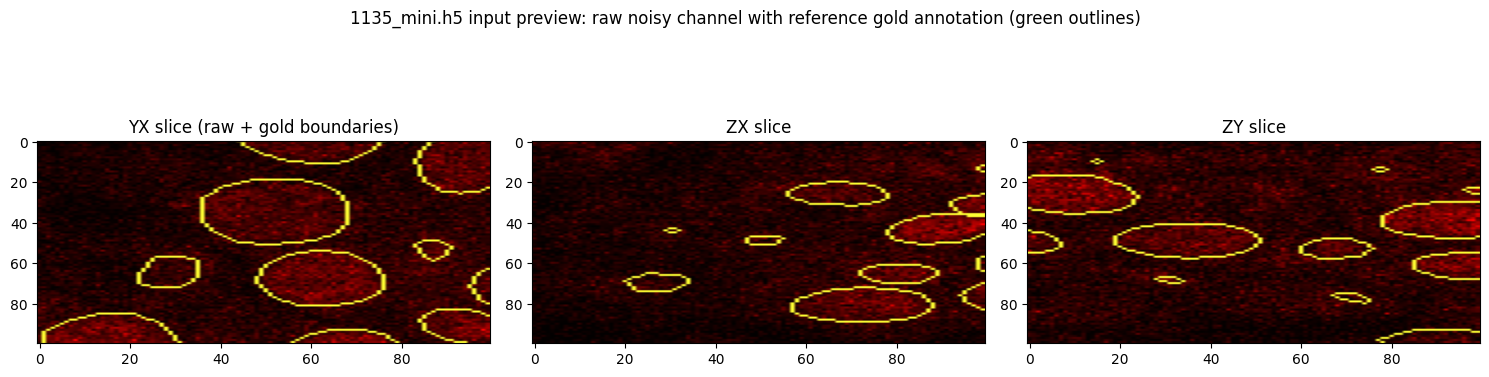

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.segmentation import find_boundaries

with h5py.File(dest, "r") as f:
    raw = f[RAW_KEY][...]
    gold = f[GOLD_KEY][...]

assert raw.shape == gold.shape
zyx_um = tuple(float(v) for v in voxel_size)  # ZYX micrometres
print("raw:", raw.shape, raw.dtype, "range", raw.min(), "-", raw.max())
print("gold:", gold.shape, gold.dtype, "| n gold labels:", len(np.unique(gold)) - 1)

def extent(ax, axis):
    # display extent in micrometres, honouring the anisotropic voxel size
    other = [s for i, s in enumerate(gold.shape) if i != axis]
    dims = [s * v for s, v in zip(other, [zyx_um[i] for i in range(3) if i != axis])]
    ax.set_xlabel("um"); ax.set_ylabel("um")
    return dims

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
mid = [s // 2 for s in raw.shape]
views = [(0, raw[mid[1], :, :], mid[2]), (1, raw[:, mid[2], :], mid[1]), (2, raw[:, :, mid[0]], mid[0])]
for ax, (axis, img, idx_gold) in zip(axes, views):
    ax.imshow(img, cmap="gray", aspect=zyx_um[1] / zyx_um[0])
    sl = [slice(None)] * 3; sl[axis] = idx_gold
    bnd = find_boundaries(gold[tuple(sl)], mode="outer")
    overlay = np.zeros(img.shape + (3,), dtype=float)
    overlay[..., 0] = np.clip(img / max(img.max(), 1), 0, 1)
    overlay[..., 1][bnd] = 1.0
    overlay[..., 0][bnd] = 1.0
    overlay[..., 2][bnd] = 0.2
    ax.imshow(overlay, aspect=zyx_um[1] / zyx_um[0])
    ax.set_title(["YX slice (raw + gold boundaries)", "ZX slice", "ZY slice"][axis])
fig.suptitle("1135_mini.h5 input preview: raw noisy channel with reference gold annotation (green outlines)")
fig.tight_layout()
plt.show()

## Model acquisition — exactly the authors' `check_models` route

`generic_plant_nuclei_3D` is the model name registered in the author package's model zoo
(`stardist/runstardist/resources/zoo.yaml`), pointing to [Zenodo record 8432366](https://zenodo.org/records/8432366):
`rdf.yaml` (4,095 B) and `stardist_weights.h5` (18,243,672 B). The authors' `check_models`
(`stardist/runstardist/utils.py:212-246`) downloads both files, writes the BioImage.IO-derived `config.json` (backbone
`resnet`, `n_rays: 96`, `grid: [2, 4, 4]`) and `thresholds.json` into `~/.runstardist/generic_plant_nuclei_3D/`, and
`StarDist3D(None, name=..., basedir=...)` then loads that folder (go-nuclear `stardist/runstardist/predict.py:18-26`).

The cell below is an explicit replica of that logic (AI-adapted glue, labelled as such): it queries the Zenodo record API
once, downloads the two files from the record's returned links, **verifies the record's md5 checksums and sizes**, and writes
`config.json`/`thresholds.json` exactly as `check_models` does. This is the only non-author glue in the pipeline; all
numerical behaviour comes from `stardist` + the author's released weights.

**日本語:** 著者の `check_models`（utils.py:212-246）と同じ経路を、Zenodo record API から検証済みチェックサム付きで再現します
（md5 とサイズを確認後、`config.json` / `thresholds.json` を rdf.yaml から生成）。数値動作はすべて
`stardist` 本体と著者の公開重みによります。

In [ ]:
import json, hashlib
import requests, yaml

MODEL_NAME = "generic_plant_nuclei_3D"
ZENODO_RECORD_ID = "8432366"
EXPECTED_MD5 = {"rdf.yaml": "1e70bd516beb6c236724e5ad91b96111",
                "stardist_weights.h5": "6801d5435360f17dce143d63d8f073aa"}  # from the verified record listing
EXPECTED_SIZE = {"rdf.yaml": 4095, "stardist_weights.h5": 18243672}

model_dir = Path.home() / ".runstardist" / MODEL_NAME
model_dir.mkdir(parents=True, exist_ok=True)

# 1) discover the exact file links from the record API (documented Zenodo route)
rec = requests.get(f"https://zenodo.org/api/records/{ZENODO_RECORD_ID}", timeout=120).json()
links = {f["key"]: f["links"]["self"] for f in rec["files"]}
assert set(EXPECTED_MD5) <= set(links), f"record files {sorted(links)}"

# 2) download + verify checksum/size, mirroring check_models
for fname in EXPECTED_MD5:
    fpath = model_dir / fname
    if fpath.exists() and len(fpath.read_bytes()) == EXPECTED_SIZE[fname]:
        pass
    else:
        print("downloading", fname, "from", links[fname])
        blob = requests.get(links[fname], timeout=600).content
        assert len(blob) == EXPECTED_SIZE[fname], f"size mismatch for {fname}"
        assert hashlib.md5(blob).hexdigest() == EXPECTED_MD5[fname], f"md5 mismatch for {fname}"
        fpath.write_bytes(blob)

# 3) write config.json / thresholds.json from rdf.yaml exactly like check_models
rdf = yaml.safe_load((model_dir / "rdf.yaml").read_text())
(model_dir / "config.json").write_text(json.dumps(rdf["config"]["stardist"]["config"]))
(model_dir / "thresholds.json").write_text(json.dumps(rdf["config"]["stardist"]["thresholds"]))
print("model directory:", model_dir)
print("stardist config:", json.dumps(rdf["config"]["stardist"]["config"]))
print("thresholds:", json.dumps(rdf["config"]["stardist"]["thresholds"]))

downloading rdf.yaml from https://zenodo.org/api/records/8432366/files/rdf.yaml/content


downloading stardist_weights.h5 from https://zenodo.org/api/records/8432366/files/stardist_weights.h5/content


model directory: /root/.runstardist/generic_plant_nuclei_3D
stardist config: {"anisotropy": [2, 1, 1], "axes": "ZYXC", "backbone": "resnet", "grid": [2, 4, 4], "n_channel_in": 1, "n_channel_out": 97, "n_classes": null, "n_dim": 3, "n_rays": 96, "net_conv_after_resnet": 128, "net_input_shape": [null, null, null, 1], "net_mask_shape": [null, null, null, 1], "rays_json": {"kwargs": {"anisotropy": [2, 1, 1], "n": 96}, "name": "Rays_GoldenSpiral"}, "resnet_activation": "relu", "resnet_batch_norm": false, "resnet_kernel_init": "he_normal", "resnet_kernel_size": [3, 3, 3], "resnet_n_blocks": 4, "resnet_n_conv_per_block": 3, "resnet_n_filter_base": 32, "train_background_reg": 0.0001, "train_batch_size": 8, "train_checkpoint": "weights_best.h5", "train_checkpoint_epoch": "weights_now.h5", "train_checkpoint_last": "weights_last.h5", "train_class_weights": [1, 1], "train_dist_loss": "mae", "train_epochs": 1000, "train_foreground_only": 0.9, "train_learning_rate": 0.0003, "train_loss_weights": [1,

Load the released model with the authors' loader form `StarDist3D(None, name=..., basedir=...)`. Recent `stardist`
(≥ 0.9) builds the **ResNet** backbone natively from the stored config (`stardist/models/model3d.py:214,257`), so the
published weights load without any conversion. We print the loaded configuration and thresholds.

**日本語:** 著者と同じ形式 `StarDist3D(None, name=..., basedir=...)` でモデルを読み込みます。stardist 0.9 系は
ResNet バックボーンを標準でサポートするため、変換なしで公開重みを読み込めます。

In [ ]:
from stardist.models import StarDist3D

model = StarDist3D(None, name=MODEL_NAME, basedir=str(model_dir.parent))
print("loaded", MODEL_NAME)
print("backbone:", model.config.backbone, "| n_rays:", model.config.n_rays, "| grid:", model.config.grid)
print("thresholds:", model.thresholds)

tf.py (53): Using Keras 2 (via 'tf_keras' package) with Tensorflow 2.16+ might work, but is not regularly tested.


Loading network weights from 'stardist_weights.h5'.
Loading thresholds from 'thresholds.json'.
Using default values: prob_thresh=0.505612, nms_thresh=0.3.
loaded generic_plant_nuclei_3D
backbone: resnet | n_rays: 96 | grid: (2, 4, 4)
thresholds: Thresholds(prob=0.5056117135432784, nms=0.3)


## Preprocessing — identical to the authors' prediction script

`predict.py:29-33` normalises each volume with `csbdeep.utils.normalize(image, 1, 99.8)` (percentile normalisation) and
applies no rescaling for this data (`rescale_factor: Null` in the published config). We apply exactly the same step and
print before/after statistics. **Adaptation note:** the authors' config also saves a probability/dist map
(`save_probability_map: True`); we request the instance segmentation only, which is the paper's delivered prediction.

**日本語:** 著者の推論スクリプト（predict.py:29-33）と同一の前処理 `normalize(image, 1, 99.8)` を適用します
（リスケールなし）。確率マップの保存は省略し、インスタンスセグメンテーションのみ取得します（明示した適応です）。

In [ ]:
from csbdeep.utils import normalize

image = normalize(raw.astype(np.float32), 1, 99.8)
print("raw     : dtype", raw.dtype, "range", float(raw.min()), "-", float(raw.max()))
print("normal  : dtype", image.dtype, "range", float(image.min()), "-", float(image.max()))

raw     : dtype uint8 range 2.0 - 255.0
normal  : dtype float32 range 0.0 - 1.5617283582687378


## Core method: 3D StarDist instance segmentation

Following `predict.py:55-63`, we call `model.predict_instances(image, n_tiles=model._guess_n_tiles(image))` — the same
tiled-prediction helper the authors' pipeline uses — and time the call. The output is a label volume of the same shape as
the input, one integer ID per nucleus instance.

**日本語:** 著者の predict.py:55-63 と同様に、`model.predict_instances` をタイリング付きで呼び出します
（n_tiles は著者実装の `_guess_n_tiles` に任せる）。出力は入力と同形状のインスタンス ID ボリュームです。

In [ ]:
import time

t0 = time.perf_counter()
segmentation, _ = model.predict_instances(
    image,
    n_tiles=model._guess_n_tiles(image),
    show_tile_progress=True,
    verbose=True,
)
elapsed = time.perf_counter() - t0
n_pred = len(np.unique(segmentation)) - 1
print(f"prediction shape: {segmentation.shape} | predicted instances: {n_pred} | wall time: {elapsed:.1f} s")

predicting instances with nms_thresh = 0.3


non-maximum suppression...


NMS took 4.0138 s
keeping 24/931 polyhedra
render polygons...
prediction shape: (100, 100, 100) | predicted instances: 24 | wall time: 15.9 s


## Scoring against the gold ground truth — the authors' released evaluation code

The authors' `evaluation/evaluate.py` (go-nuclear @ `4b45647b`, MIT) defines `SegmentationMetrics` and `AveragePrecision`
(average precision over the IoU range 0.50–0.95 with step 0.05, following the Kaggle 2018 Data Science Bowl definition).
The next cell is the authors' code copied with **one documented compatibility change**: `contingency_table(gt, seg).A`
(line 15 of the original) is replaced by `.toarray()` because scipy ≥ 1.14 removed the sparse-matrix `.A` alias, and the
Colab runtime ships a newer scipy. Everything else is verbatim (only this provenance header was added); the code is short
enough to keep visible in the notebook.

**日本語:** 続くセルは著者の `evaluation/evaluate.py` のコピーです。唯一の変更は、scipy 1.14 以上で削除された
疎行列 `.A` エイリアスへの対応として `.toarray()` を用いた 1 行のみ（出典ヘッダに明記）。
IoU 0.50–0.95 の Average Precision を gold アノテーションに対して計算します。

In [ ]:
# Copy of kreshuklab/go-nuclear evaluation/evaluate.py
# (commit 4b45647b64c3b1544bf69914b8415965bf8f5bc7, MIT license; only this header and the
#  scipy>=1.14 compatibility line noted below were changed).
import numpy as np
import pandas as pd
from skimage.metrics import contingency_table


def _relabel(input):
    unique_labels, relabelled_flat_array = np.unique(input, return_inverse=True)
    return unique_labels, relabelled_flat_array.reshape(input.shape)


def _iou_matrix(gt, seg):
    unique_labels_gt, gt = _relabel(gt)
    unique_labels_seg, seg = _relabel(seg)

    n_inter = contingency_table(gt, seg).toarray()  # [compat] original: contingency_table(gt, seg).A (removed in scipy>=1.14)

    n_gt = n_inter.sum(axis=1, keepdims=True)
    n_seg = n_inter.sum(axis=0, keepdims=True)

    n_union = n_gt + n_seg - n_inter

    iou_matrix = n_inter / n_union
    # make sure that the values are within [0,1] range
    assert 0 <= np.min(iou_matrix) <= np.max(iou_matrix) <= 1

    return iou_matrix, unique_labels_gt, unique_labels_seg


def precision(tp, fp, fn):
    return tp / (tp + fp) if tp > 0 else 0


def recall(tp, fp, fn):
    return tp / (tp + fn) if tp > 0 else 0


def accuracy(tp, fp, fn):
    return tp / (tp + fp + fn) if tp > 0 else 0


def f1(tp, fp, fn):
    return (2 * tp) / (2 * tp + fp + fn) if tp > 0 else 0


class SegmentationMetrics:
    """
    Computes precision, recall, accuracy, f1 score for a given ground truth and predicted segmentation.
    Contingency table for a given ground truth and predicted segmentation is computed eagerly upon construction
    of the instance of `SegmentationMetrics`.
    Args:
        gt (ndarray): ground truth segmentation
        seg (ndarray): predicted segmentation
    """

    def __init__(self, gt, seg):
        self.iou_matrix, self.unique_labels_gt, self.unique_labels_seg = _iou_matrix(gt, seg)

        self.df_iou_matrix = pd.DataFrame(self.iou_matrix, index=self.unique_labels_gt, columns=self.unique_labels_seg)
        argmax = np.argmax(self.iou_matrix, axis=1)
        matching_labels = self.unique_labels_seg[argmax]
        self.df_iou_matrix['matching_labels'] = matching_labels
        max_iou = np.max(self.iou_matrix, axis=1)
        self.df_iou_matrix['max_iou'] = max_iou

    def metrics(self, iou_threshold):
        """
        Computes precision, recall, accuracy, f1 score at a given IoU threshold
        """
        # ignore background
        iou_matrix = self.iou_matrix[1:, 1:]
        detection_matrix = (iou_matrix > iou_threshold).astype(np.uint8)
        n_gt, n_seg = detection_matrix.shape

        # if the iou_matrix is empty or all values are 0
        trivial = min(n_gt, n_seg) == 0 or np.all(detection_matrix == 0)
        if trivial:
            tp = fp = fn = 0
        else:
            # count non-zero rows to get the number of TP
            tp = np.count_nonzero(detection_matrix.sum(axis=1))
            # count zero rows to get the number of FN
            fn = n_gt - tp
            # count zero columns to get the number of FP
            fp = n_seg - np.count_nonzero(detection_matrix.sum(axis=0))

        return {
            'precision': precision(tp, fp, fn),
            'recall': recall(tp, fp, fn),
            'accuracy': accuracy(tp, fp, fn),
            'f1': f1(tp, fp, fn),
        }


class AveragePrecision:
    """
    Average precision taken for the IoU range (0.5, 0.95) with a step of 0.05 as defined in:
    https://www.kaggle.com/stkbailey/step-by-step-explanation-of-scoring-metric
    """

    def __init__(self, iou=None):
        if iou is not None:
            self.iou_range = [iou]
        else:
            self.iou_range = np.linspace(0.50, 0.95, 10)

    def __call__(self, input_seg, gt_seg):
        if np.all(gt_seg == gt_seg.flat[0]):
            return 1.0

        sm = SegmentationMetrics(gt_seg, input_seg)
        df_iou_matrix = sm.df_iou_matrix
        acc = [sm.metrics(iou)['accuracy'] for iou in self.iou_range]
        return acc, self.iou_range, df_iou_matrix

Compute the average-precision curve of the prediction against the shipped gold annotation, plus precision/recall/F1 at the
commonly reported IoU thresholds 0.5 and 0.75, and export a small CSV. This scores the *single crop* — it does not reproduce
the paper's dataset-level Table 1 values (computed on full volumes).

**日本語:** 予測と gold アノテーションの AP 曲線、IoU 0.5 / 0.75 での precision・recall・F1 を計算し、CSV に書き出します。
単一クロップのスコアであり、論文のデータセット全体の表の再現ではありません。

In [ ]:
ap = AveragePrecision()
accs, iou_range, _ = ap(segmentation, gold)
mean_ap = float(np.mean(accs))

rows = []
for thr in (0.5, 0.75):
    m = SegmentationMetrics(gold, segmentation).metrics(thr)
    rows.append({"iou_threshold": thr, **{k: round(float(v), 4) for k, v in m.items()}})
rows.append({"iou_threshold": "mAP 0.50:0.95:0.05", **{k: "" for k in ("precision", "recall", "f1")},
             "accuracy": round(mean_ap, 4)})
metrics_df = pd.DataFrame(rows)
display(metrics_df)

metrics_df.to_csv("/content/gonuclear_1135mini_ap.csv", index=False)
# Context: nuclei truncated by the crop borders are annotated in the gold labels but cannot be
# detected as complete objects by StarDist — this depresses recall/FN on a small crop.
border = np.unique(np.concatenate([gold[0], gold[-1], gold[:, 0], gold[:, -1], gold[..., 0], gold[..., -1]]))
n_border = len(set(border.tolist()) - {0})
print(f"gold instances: {len(np.unique(gold)) - 1} (of which {n_border} touch the crop border) | predicted instances: {n_pred}")
print(f"mAP (single crop): {mean_ap:.4f}")
print("saved CSV: /content/gonuclear_1135mini_ap.csv")

,iou_threshold,precision,recall,accuracy,f1
0,0.5,1.0,0.4444,0.4444,0.6154
1,0.75,1.0,0.4444,0.4444,0.6154
2,mAP 0.50:0.95:0.05,,,0.3808,


gold instances: 54 (of which 43 touch the crop border) | predicted instances: 24
mAP (single crop): 0.3808
saved CSV: /content/gonuclear_1135mini_ap.csv


Plot the accuracy-vs-IoU curve (this graph is created for this notebook from the actual scored crop; the authors do not
publish this exact curve).

**日本語:** 実際にスコアリングしたクロップから accuracy–IoU 曲線を描きます（本ノートブック用の追加可視化であり、
著者の図ではありません）。

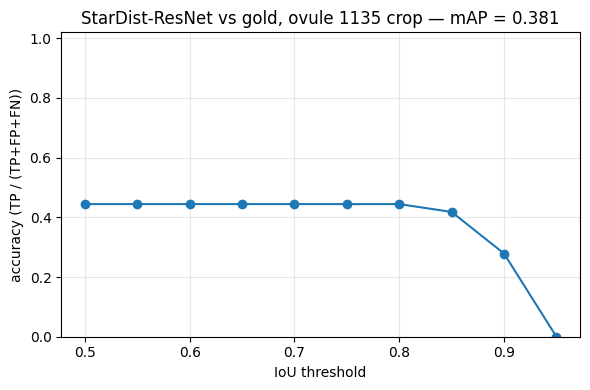

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(iou_range, accs, marker="o")
ax.set_xlabel("IoU threshold")
ax.set_ylabel("accuracy (TP / (TP+FP+FN))")
ax.set_ylim(0, 1.02)
ax.grid(alpha=0.3)
ax.set_title(f"StarDist-ResNet vs gold, ovule 1135 crop — mAP = {mean_ap:.3f}")
fig.tight_layout()
plt.show()

Final comparison view of the same orthogonal slices: raw input, reference gold annotation, and the model prediction,
with instance boundaries overlaid. Reference annotation and model prediction are labelled separately.

**日本語:** 同じ断面について「生入力」「gold 参照アノテーション」「モデル予測」を並べて比較します。
参照アノテーションとモデル予測は区別して表示します。

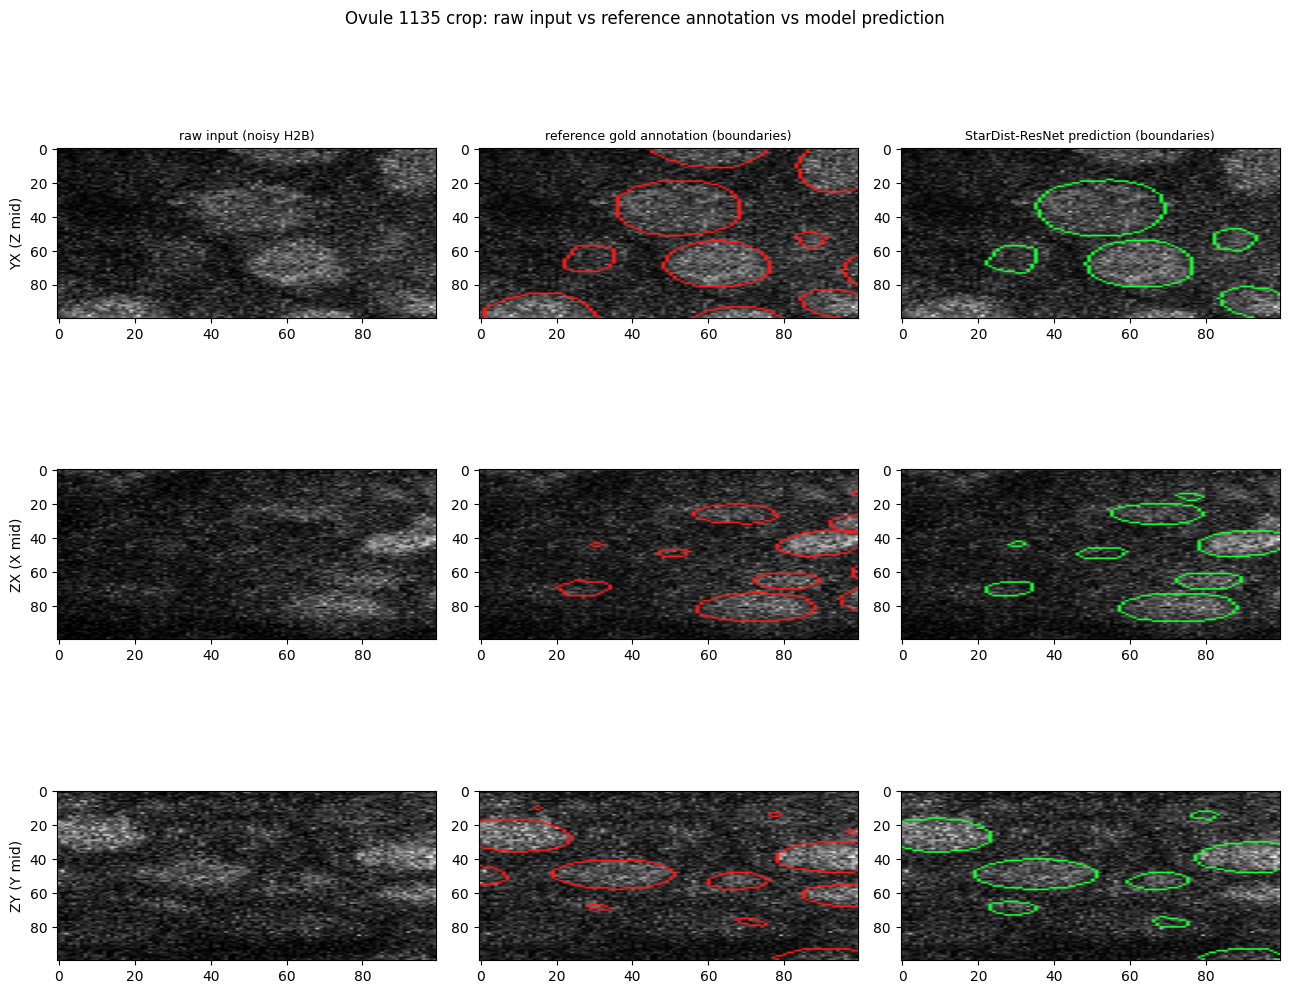

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(13, 11))
mid = [s // 2 for s in raw.shape]
plane_slices = {0: raw[mid[1], :, :], 1: raw[:, mid[2], :], 2: raw[:, :, mid[0]]}
plane_names = {0: "YX (Z mid)", 1: "ZX (X mid)", 2: "ZY (Y mid)"}
for axis, base in plane_slices.items():
    gold_b = find_boundaries(np.take(gold, mid[axis], axis=axis), mode="outer")
    pred_b = find_boundaries(np.take(segmentation, mid[axis], axis=axis), mode="outer")
    base_n = base.astype(float) / max(base.max(), 1)
    panels = [(base_n, None, "raw input (noisy H2B)"),
              (base_n, gold_b, "reference gold annotation (boundaries)"),
              (base_n, pred_b, "StarDist-ResNet prediction (boundaries)")]
    for col, (img, bnd, title) in enumerate(panels):
        ax = axes[axis][col]
        ax.imshow(img, cmap="gray", aspect=zyx_um[1] / zyx_um[0])
        if bnd is not None:
            ov = np.zeros(img.shape + (3,)); ov[..., 0] = img; ov[..., 1] = img; ov[..., 2] = img
            ov[bnd] = [1.0, 0.1, 0.1] if col == 1 else [0.1, 1.0, 0.2]
            ax.imshow(ov, aspect=zyx_um[1] / zyx_um[0])
        if axis == 0:
            ax.set_title(title, fontsize=9)
        if col == 0:
            ax.set_ylabel(plane_names[axis])
fig.suptitle("Ovule 1135 crop: raw input vs reference annotation vs model prediction")
fig.tight_layout()
plt.show()

## Interpretation, differences from the paper, and validation record

- **What this shows:** the released platinum StarDist-ResNet model (`generic_plant_nuclei_3D`, Zenodo 8432366) segments
  3D nuclei in the authors' own validation crop, and the authors' released scorer (`evaluation/evaluate.py`, with the one
  scipy-compatibility line noted above) quantifies agreement with the shipped gold annotation (see the mAP and the
  precision/recall table in the outputs above).
- **Why the score is not a paper reference value:** in a 100³-voxel crop many gold-labelled nuclei are truncated by the
  crop borders; the count of border-touching gold labels is printed above. Such partially visible nuclei cannot be detected
  as complete objects, which depresses the measured AP relative to the paper's full-volume evaluation. The crop is the
  authors' own pipeline-test sample; the paper reports AP only on full test volumes (Tables rendered as images in PMC).
- **Differences from the paper:** a single ~0.8 MB crop of validation ovule 1135 is scored, not the full test volumes or
  the paper's Tables 1–5; no probability-map output; no training or benchmarking. Values are therefore **not comparable**
  to the paper's dataset-level AP.
- **AI-adapted glue (labelled):** the model-download cell replicates the authors' `check_models`; everything else runs
  the authors' own pipeline/evaluation code on the `stardist` package with legacy Keras (`TF_USE_LEGACY_KERAS=1`,
  the combination tested by stardist's CI for Python 3.12 + latest TF 2).
- **Validation record (this run):** executed top-to-bottom on a fresh Google Colab **CPU** runtime on 2026-10-07; measured
  wall times are printed in the outputs above (setup, model download, inference). One-example run — dataset-level accuracy
  of the paper remains unverified.

**日本語:** 本ノートブックは公開済みプラチナモデルと著者の評価コードを、著者同梱の検証クロップ上でそのまま実行する
最小デモです。単一クロップのスコアであり、論文のデータセットレベルの精度（Table 1–5）とは比較できません。
モデルダウンロード部分のみ著者の `check_models` を再現した AI 生成グルーである点に注意してください。

## References

- Vijayan et al., *Development* 151(14): dev202800 (2024). DOI [10.1242/dev.202800](https://doi.org/10.1242/dev.202800), PMC [PMC11273294](https://pmc.ncbi.nlm.nih.gov/articles/PMC11273294/).
- Code: [kreshuklab/go-nuclear](https://github.com/kreshuklab/go-nuclear) @ `4b45647b64c3b1544bf69914b8415965bf8f5bc7` (MIT).
- Model: [Zenodo 8432366](https://zenodo.org/records/8432366) "StarDist Plant Nuclei 3D ResNet"; also on [BioImage.IO `modest-octopus`](https://bioimage.io/#/artifacts/modest-octopus).
- Data: [BioImage Archive S-BIAD1026](https://www.ebi.ac.uk/biostudies/BioImages/studies/S-BIAD1026); input crop `1135_mini.h5` from the author repository test data.
- Tools: [stardist](https://github.com/stardist/stardist) 0.9.2, [csbdeep](https://github.com/CSBDeep/CSBDeep) ≥ 0.8.2, TensorFlow (Colab preinstalled) with `tf_keras`.